PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

In [1]:
# Instala dependencias
!pip install -q --user --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy "numpy<2" cloudpickle==3.1.1
!pip install -q --user --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from numerapi import NumerAPI
from scipy import stats
import lightgbm as lgb
import pandas as pd
import numpy as np
import cloudpickle
import json

C:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


1.- DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha. 

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [3]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [4]:
# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
# napi.download_dataset(f"{DATA_VERSION}/train.parquet");
# napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["medium"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

small 42
medium 705
all 2376


,era,target,feature_able_deprived_nona,feature_ablest_inflexional_egeria,feature_absorbable_hyperalgesic_mode,feature_accoutered_revolute_vexillology,feature_acetose_crackerjack_needlecraft,feature_acheulian_conserving_output,feature_acronychal_bilobate_stevenage,feature_acrylic_gallic_wine,...,feature_working_jain_acromegaly,feature_wrapround_chrestomathic_timarau,feature_xanthic_transpadane_saleswoman,feature_xanthochroid_petrified_gutenberg,feature_zincy_cirrhotic_josh,feature_zippy_trine_diffraction,feature_zonal_snuffly_chemism,feature_zygotic_middlebrow_caribbean,feature_zymolytic_intertidal_privet,feature_zymotic_windswept_cooky
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,1,2,3,2,3,2,2,2,...,2,0,3,2,4,3,2,1,0,0
n003bba8a98662e4,0001,0.25,3,2,4,1,0,2,3,2,...,2,0,0,2,0,0,2,0,0,0
n003bee128c2fcfc,0001,0.75,1,2,0,2,4,2,0,2,...,2,3,3,2,2,3,2,2,2,4
n0048ac83aff7194,0001,0.25,1,2,3,4,0,2,3,2,...,2,0,2,1,1,4,2,0,2,1
n0055a2401ba6480,0001,0.25,3,2,3,4,1,2,4,2,...,2,1,3,3,2,4,2,4,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,3,3,2,2,3,0,4,3,...,3,3,3,0,3,2,0,4,2,4
nffc9844c1c7a6a9,0573,0.25,0,1,2,1,3,2,2,1,...,1,0,1,1,0,3,0,2,1,2
nffd79773f4109bb,0573,0.50,3,1,1,1,3,2,2,0,...,1,0,2,1,2,4,4,0,1,2


ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.

# Dataset

### Muestra las gráficas que consideres necesarias y explica su importancia.

Correlación media: 0.0024
Correlación máxima: 0.0119


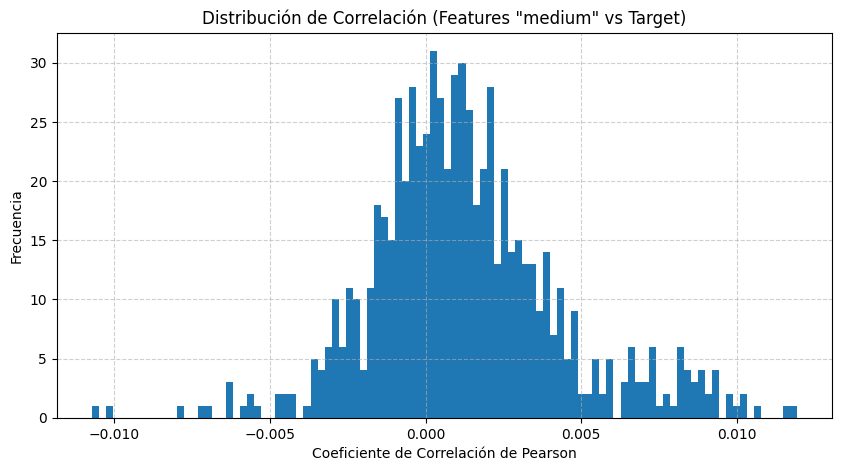

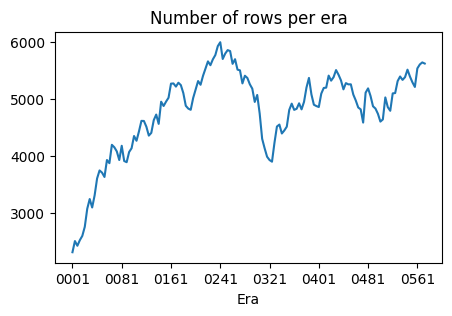

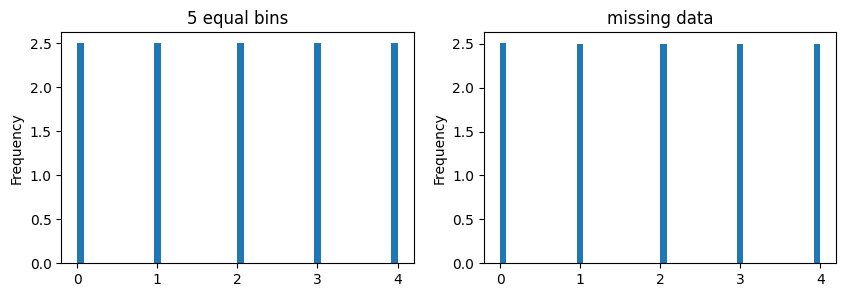

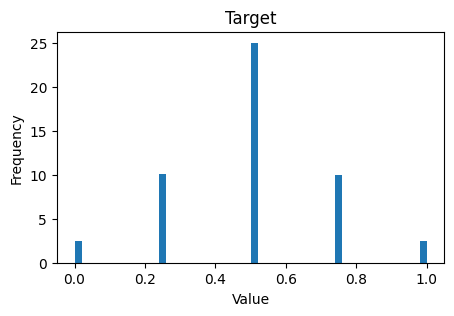

In [5]:
# Calcular la correlación de Pearson de todas las features "medium" con el target
correlations = train[feature_set].apply(lambda x: np.corrcoef(x, train["target"])[0, 1])
correlations = correlations.dropna()

print(f"Correlación media: {correlations.abs().mean():.4f}")
print(f"Correlación máxima: {correlations.abs().max():.4f}")

# Visualizar la distribución de las correlaciones
plt.figure(figsize=(10, 5))
correlations.plot(kind='hist', bins=100, title='Distribución de Correlación (Features "medium" vs Target)')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show();

# Muestra el número de filas por era
plt.figure(figsize=(5, 3))
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era");
plt.show();

# Compara la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);

# Histograma (densidad) de "target"
plt.figure(figsize=(5, 3))
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);
plt.show();

#### Distribución de Correlación
Esta gráfica es, quizas, la más importante de toda la exploración. Muestra la correlación entre cada una de las 705 features del conjunto "medium" y la variable target. Es una grafica directa del poder predictivo individual de los datos.

La gráfica valida por que esta es "la práctica de machine learning más difícil". La distribución esta centrada en 0.0, y casi todas las correlaciones caen entre -0.01 y 0.01.

#### Número de filas por era
Es importante porque muestra cuantos puntos de datos de las acciones hay en cada era.

La grafica demuestra que el dataset no es estable en el tiempo. El numero de acciones que se analizan cambia constantemente.

#### Equal bins y Missing data
Estas graficas son importantes ya que comparan la distribución de una feature especifica en dos momentos distintos

La grafica 5 equal bins confirma visualmente el enunciado, las features no son continuas, sino que han sido opacadas en 5 valores exactos: 0, 1, 2, 3 y 4. Esto justifica por qué es necesario escalar los datos para un modelo de árbol como LGBM.

La grafica missing data es clave. Muestra un unico pico gigante en el valor 2(Small). El enunciado explica que si faltan datos todos los valores se establecen en 2. Esta gráfica demuestra esa estrategia. Nos dice que en las primeras eras, los datos eran de peor calidad (o faltaban) y que el valor 2 es ambiguo.

#### Target
Esta grafica es clave. Muestra la correlación entre las 705 features (medium) y el target.

Muestra la dificultad de la practica, ya que la distribución esta centrada en 0.0 y casi todas las correlaciones son mínimas, entre -0.01 y 0.01. Esto significa que ninguna feature sola es un buen predictor, El modelo debera combinar cientos de estas señales débiles para encontrar un patron.


FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [6]:
# Número de características
len(feature_set)

705

Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Específicamente, es una medida de rendimientos "específicos de acciones" que no se "explican" por tendencias más amplias en el mercado, país, sector o "factores" bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Nuevamente, esta fuerte estandarización de los valores de target tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

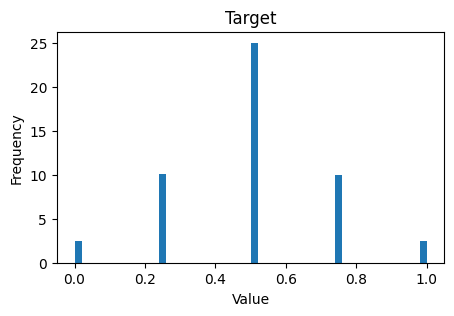

In [7]:
# Histograma (densidad) de "target"
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

2.- MODELING

Entrenamiento del modelo:

Eres libre de utilizar cualquier algoritmo visto en clase. Pero, en este ejemplo, usaremos LGBMRegressor, basado en árboles de decisión para predecir variables continuas. Es una opción popular para las predicciones de este tipo.

### Reduce el conjunto de datos, eliminando filas (si así lo consideras), si se vuelve muy pesado el entrenamiento. Justifícalo.

In [8]:
feature_cols = feature_set
nunique = train[feature_cols].nunique()
constant_features = nunique[nunique == 1].index.tolist()
null_counts = train[feature_cols].isnull().sum()
features_with_nulls = null_counts[null_counts > 0]
low_variance_features = []

# Comprobar características constantes
if constant_features:
    print(f"Se encontraron {len(constant_features)} características constantes:")
    print(constant_features)
else:
    print("No se encontraron características constantes (con varianza cero).")

# Comprobar varianza muy baja
for col in feature_cols:
    counts = train[col].value_counts(normalize=True)
    if counts.iloc[0] > 0.99:
        low_variance_features.append(col)
if low_variance_features:
    print(f"Se encontraron {len(low_variance_features)} características con varianza muy baja:")
else:
    print("No se encontraron características con varianza extremadamente baja.")
    
# Comprobar nulos
if not features_with_nulls.empty:
    print(f"Se encontraron {len(features_with_nulls)} características con valores nulos:")
    print(features_with_nulls)
else:
    print("No se encontraron valores nulos (NaN) en las características seleccionadas.")

No se encontraron características constantes (con varianza cero).
No se encontraron características con varianza extremadamente baja.
No se encontraron valores nulos (NaN) en las características seleccionadas.


Al no econtrar ningun nulo ni alguna caracteristica con una varianza minima, no merece la pena reducir mas el conjunto de datos, ya que ya fue reducido cada 4 eras y los datos que tenemos son muy debiles, en la gráfica de correlación, la relación entre las características y el objetivo es extremadamente baja.
Reducir aun mas el número de eras o de puntos por era haria que las metricas de rendimiento, como la correlación media o Sharpe fueran menos fiables.

Aunque reducir mas filas aceleraria el entrenamiento, el riesgo de perder información importante y obtener un modelo menos fiable es demasiado alto para este problema tan sensible al ruido. Por tanto no se reducira mas el dataset.

In [9]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html 
import lightgbm as lgb #En mi mac, tuve que instalar libomp: "brew install libomp"

# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1
)

# This will take a few minutes 🍵
model.fit(
  train[feature_set],
  train["target"]
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018380 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3525
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 705
[LightGBM] [Info] Start training from score 0.500008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Ahora hagamos algunas predicciones con los datos de validación para evaluar el rendimiento de nuestro modelo.

In [10]:
# Descarga validation data 
# Esto tomará unos pocos minutos 🍵
# napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

# Carga el validation data, filtrando por data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Genera predicciones respecto a las características de validación fuera de la muestra.
# Esto tomará unos pocos minutos 🍵
validation["prediction"] = model.predict(validation[feature_set])
validation[["era", "prediction", "target"]]

,era,prediction,target
id,,,
n000c290e4364875,0579,0.491249,0.50
n002a15bc5575bbb,0579,0.505177,0.25
n00309caaa0f955e,0579,0.517842,0.75
n0039cbdcf835708,0579,0.495611,0.50
n004143458984f89,0579,0.496297,0.50
...,...,...,...
nffc45fef92f9990,1183,0.501589,0.50
nffcd993886ef112,1183,0.479586,0.25
nffd2f8483ddb3cc,1183,0.505694,0.25


Evaluación del rendimiento:

La métrica de puntuación principal que usaremos se llama CORR (practica_corr), que es una variante específica de para este caso de uso del coeficiente de correlación de Pearson.

Esta métrica está diseñada para "alinear los incentivos" entre el modelo y el desempeño de un fondo de inversión. Es decir, un modelo con una buena puntuación CORR debería ayudar a un inversor a obtener buenos rendimientos.

### Comprueba que mejore la precisión eliminando características poco relevantes. Explica qué métodos o criterios has usado para eliminar

In [11]:


# Función auxiliar para calcular la correlación
def practica_corr(preds, target):
    if preds.std() == 0 or target.std() == 0:
        return 0
    return np.corrcoef(preds, target)[0, 1]


# Esto evitará repetir el código para cada porcentaje
def train_and_evaluate(features, train_data, validation_data, model_params):
    print(f"Entrenando modelo con {len(features)} características")
    
    # Definir el modelo con los mismos hiperparámetros
    model = lgb.LGBMRegressor(**model_params)
    
    # Entrenar
    model.fit(
        train_data[features],
        train_data["target"]
    )
    
    print("Generando predicciones de validación...")
    # Generar predicciones en validación
    predictions = model.predict(validation_data[features])
    
    # Crear una columna temporal para calcular la correlación
    validation_data['prediction_temp'] = predictions
    
    print("Calculando métricas de rendimiento por era...")
    # Calcular correlación por era usando la función 'practica_corr'
    per_era_corr = validation_data.groupby("era").apply(
        lambda x: practica_corr(x["prediction_temp"], x["target"])
    )
    
    # Limpiar la columna temporal
    validation_data.drop('prediction_temp', axis=1, inplace=True)
    
    # Calcular métricas resumen
    corr_mean = per_era_corr.mean()
    corr_std = per_era_corr.std(ddof=0)
    corr_sharpe = corr_mean / corr_std
    max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

    metrics = {
        "mean": corr_mean,
        "std": corr_std,
        "sharpe": corr_sharpe,
        "max_drawdown": max_drawdown
    }
    
    return metrics

# Setup
all_metrics = {}

# Definir Hiperparámetros
model_params = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'max_depth': 5,
    'num_leaves': 2**5 - 1,
    'colsample_bytree': 0.1
}

# Entrenar y evaluar el modelo original (100% de las características)
print("Entrenando modelo original (100% de features)...")
metrics_original = train_and_evaluate(feature_set, train, validation.copy(), model_params)

# Guardar métricas del modelo original
all_metrics["Original (100%)"] = metrics_original

# Obtener importancia de características del modelo original
feature_importances = pd.DataFrame({
    'feature': feature_set,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

total_features = len(feature_importances)
print(f"Número total de características: {total_features}")

# Porcentajes de features a probar
percentiles_to_test = [0.75, 0.50, 0.25]

# Ejecutar pruebas reduciendo el número de características
for percentile in percentiles_to_test:
    n_top_features = int(total_features * percentile)
    features_name = f"Top {percentile*100:.0f}% ({n_top_features} feats)"
    
    print(f"\nProbando con {features_name}")
    
    # Obtener la lista de N características principales
    top_features_list = feature_importances.head(n_top_features)['feature'].tolist()
    
    # Entrenar y evaluar
    metrics = train_and_evaluate(top_features_list, train, validation.copy(), model_params)
    
    # Guardar métricas
    all_metrics[features_name] = metrics

# Mostrar resultados finales
print("\nComparación Final de Métricas:")
comparison_df = pd.DataFrame(all_metrics)
print(comparison_df)

# Conclusión
print("\n--- Conclusión General ---")
best_mean_model = comparison_df.loc['mean'].idxmax()
best_sharpe_model = comparison_df.loc['sharpe'].idxmax()

print(f"Mejor precisión (mean):   {best_mean_model} (Valor: {comparison_df.loc['mean', best_mean_model]:.6f})")
print(f"Mejor estabilidad (sharpe): {best_sharpe_model} (Valor: {comparison_df.loc['sharpe', best_sharpe_model]:.6f})")

if best_mean_model == best_sharpe_model and best_mean_model != "Original (100%)":
    print(f"\nResultado: ¡Óptimo! Usar las '{best_mean_model}' mejora tanto la precisión como la estabilidad.")
elif best_mean_model != "Original (100%)" or best_sharpe_model != "Original (100%)":
    print("\nResultado: ¡Mejora parcial! Reducir el número de características mejora al menos una de las métricas clave.")
else:
    print("\nResultado: El modelo original (100% de features) sigue siendo el mejor.")

Entrenando modelo original (100% de features)...
Entrenando modelo con 705 características
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.746889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3525
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 705
[LightGBM] [Info] Start training from score 0.500008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Generando predicciones de validación...
Calculando métricas de rendimiento por era...


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\2495055387.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation_data.groupby("era").apply(


Número total de características: 705

Probando con Top 75% (528 feats)
Entrenando modelo con 528 características
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014668 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2640
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 528
[LightGBM] [Info] Start training from score 0.500008
Generando predicciones de validación...
Calculando métricas de rendimiento por era...


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\2495055387.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation_data.groupby("era").apply(



Probando con Top 50% (352 feats)
Entrenando modelo con 352 características
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.369513 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1760
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 352
[LightGBM] [Info] Start training from score 0.500008
Generando predicciones de validación...
Calculando métricas de rendimiento por era...


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\2495055387.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation_data.groupby("era").apply(



Probando con Top 25% (176 feats)
Entrenando modelo con 176 características
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 880
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 176
[LightGBM] [Info] Start training from score 0.500008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Generando predicciones de validación...
Calculando métricas de rendimiento por era...


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\2495055387.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation_data.groupby("era").apply(



Comparación Final de Métricas:
              Original (100%)  Top 75% (528 feats)  Top 50% (352 feats)  \
mean                 0.027900             0.028050             0.027307   
std                  0.022639             0.022489             0.022541   
sharpe               1.232403             1.247264             1.211415   
max_drawdown         0.036805             0.040117             0.033372   

              Top 25% (176 feats)  
mean                     0.026803  
std                      0.022213  
sharpe                   1.206616  
max_drawdown             0.040556  

--- Conclusión General ---
Mejor precisión (mean):   Top 75% (528 feats) (Valor: 0.028050)
Mejor estabilidad (sharpe): Top 75% (528 feats) (Valor: 1.247264)

Resultado: ¡Óptimo! Usar las 'Top 75% (528 feats)' mejora tanto la precisión como la estabilidad.


Para eliminar las características poco relevantes, he usado el metodo feature selection basado en la importancia que calcula el propio modelo LGBM. He probado a entrenar el modelo usando solo el Top 75%, 50% y 25% de las características mas importantes.

Las metricas consiguen subir ligeramente al eliminar las caracteristicas menos relevantes al usar el Top 75%. Esto, aparte de mejorar el rendimiento del modelo, eleva la puntuación, ya que elimina ruido y características que podrían entorpecer la prediccion. Sin embargo, vemos como eliminar el 50% o 75% de ellas es excesivo y las metricas disminuyen. Esta última opción (Top 50%) podría seguir siendo válida si se quiere reducir mucho el coste computacional, ya que en el 50% las métricas no bajan demasiado y el coste se reduce a la mitad.

### Aplica PCA para reducir la dimensionalidad. ¿Cuántas características resultan y por qué?

PCA ajustado con 705 componentes.


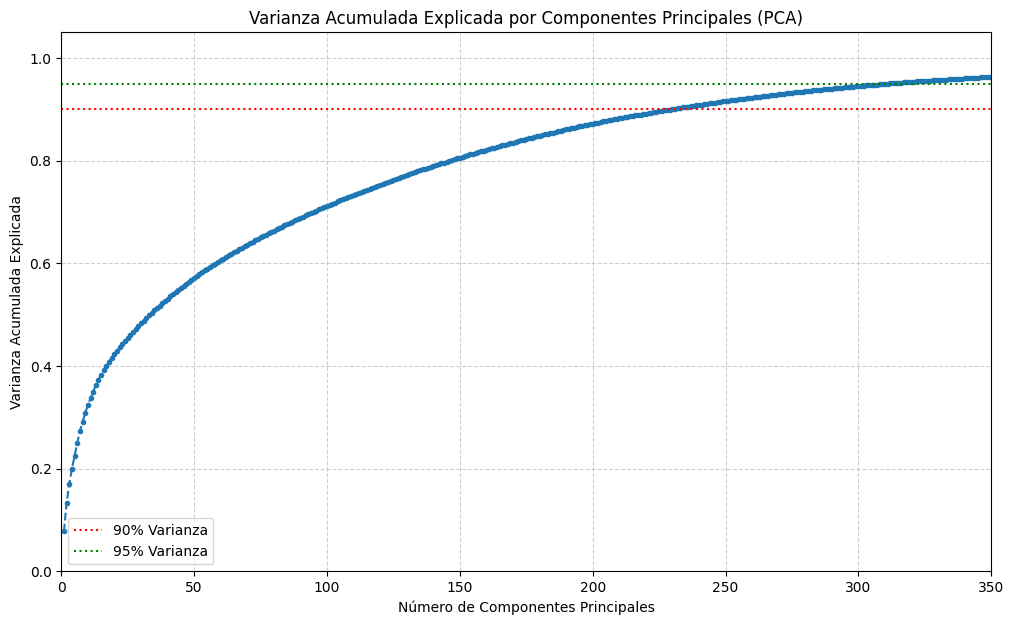


Resultados del Analisis
Para capturar el 90% de la varianza, se necesitan: 230 componentes.
Para capturar el 95% de la varianza, se necesitan: 312 componentes.


In [12]:
# Escalar los datos (PCA es sensible a la escala)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(train[feature_set])

# Aplicar PCA (sin truncar) para analizar la varianza
pca = PCA(n_components=None)
pca.fit(features_scaled)
print("PCA ajustado con 705 componentes.")

# Calcular la varianza acumulada
explained_variance_cumulative = np.cumsum(pca.explained_variance_ratio_)

# Graficar la varianza acumulada
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(explained_variance_cumulative) + 1), explained_variance_cumulative, marker='.', linestyle='--')
plt.title('Varianza Acumulada Explicada por Componentes Principales (PCA)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True, linestyle='--', alpha=0.6)

# Añadir líneas de referencia para umbrales comunes
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Varianza')
plt.axhline(y=0.95, color='g', linestyle=':', label='95% Varianza')
plt.legend()

# Limitar el eje X para ver el "codo" más claramente
# Ajusta este límite si el "codo" ocurre más tarde
plt.xlim(0, 350)
plt.ylim(0, 1.05)
plt.show()

# Encontrar el número de componentes para un umbral (ej. 90%)
n_components_90 = np.argmax(explained_variance_cumulative >= 0.90) + 1
print(f"\nResultados del Analisis")
print(f"Para capturar el 90% de la varianza, se necesitan: {n_components_90} componentes.")

n_components_95 = np.argmax(explained_variance_cumulative >= 0.95) + 1
print(f"Para capturar el 95% de la varianza, se necesitan: {n_components_95} componentes.")

230 caracteristicas si quieres el 90% de la varianza.
312 caracteristicas si quieres el 95% de la varianza.

El objetivo de PCA es reducir la dimensionalidad, en este caso de 705 features a un número menor 230, eliminando el ruido y conservando la varianza.

Esas 230 nuevos componentes son suficientes para explicar el 90% de la varianza total que estaba contenida en las 705 características originales. Se asume que el 10% de la varianza restante es ruido y puede ser descartado para, potencialmente, mejorar el rendimiento del modelo, reduciendo el coste computacional.

### Comprueba y explica por qué mejora, o no, la precisión respecto a entrenar el modelo con todas las features.

In [13]:
# Definir parametros
N_COMPONENTS = 230  # 90% de varianza

# Calcular metricas del modelo original
print("Calculando métricas del modelo original (100% de features)...")
original_metrics = train_and_evaluate(feature_set, train, validation.copy(), {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'max_depth': 5,
    'num_leaves': 2**5 - 1,
    'colsample_bytree': 0.1
})

original_metrics_df = pd.DataFrame(original_metrics, index=["Original (705 feats)"]).T

# Preparar Datos
print(f"\nPreparando datos: Escalando y aplicando PCA (n_components={N_COMPONENTS})...")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train[feature_set])
validation_scaled = scaler.transform(validation[feature_set])

pca = PCA(n_components=N_COMPONENTS, random_state=42)
train_pca = pca.fit_transform(train_scaled)
validation_pca = pca.transform(validation_scaled)

print(f"Datos transformados. Forma de Train PCA: {train_pca.shape}")

# Entrenar Nuevo Modelo con PCA
pca_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=2**5 - 1,
    colsample_bytree=0.1,
    verbose=-1
)

print("Entrenando modelo con datos transformados por PCA...")
pca_model.fit(train_pca, train["target"])

# Evaluar Nuevo Modelo
validation['prediction_pca'] = pca_model.predict(validation_pca)
per_era_corr_pca = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_pca"], x["target"]))

corr_mean_pca = per_era_corr_pca.mean()
corr_std_pca = per_era_corr_pca.std(ddof=0)
corr_sharpe_pca = corr_mean_pca / corr_std_pca
max_drawdown_pca = (per_era_corr_pca.cumsum().expanding(min_periods=1).max() - per_era_corr_pca.cumsum()).max()

pca_metrics_df = pd.DataFrame({
    "mean": corr_mean_pca,
    "std": corr_std_pca,
    "sharpe": corr_sharpe_pca,
    "max_drawdown": max_drawdown_pca
}, index=[f"PCA ({N_COMPONENTS} feats)"]).T

# Comparar Resultados
print("\nComparación de Métricas Original vs PCA")
comparison_df = pd.concat([original_metrics_df, pca_metrics_df], axis=1)
print(comparison_df)

Calculando métricas del modelo original (100% de features)...
Entrenando modelo con 705 características
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3525
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 705
[LightGBM] [Info] Start training from score 0.500008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Generando predicciones de validación...
Calculando métricas de rendimiento por era...


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\2495055387.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation_data.groupby("era").apply(



Preparando datos: Escalando y aplicando PCA (n_components=230)...
Datos transformados. Forma de Train PCA: (688184, 230)
Entrenando modelo con datos transformados por PCA...


C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Comparación de Métricas Original vs PCA
              Original (705 feats)  PCA (230 feats)
mean                      0.027900         0.015371
std                       0.022639         0.018770
sharpe                    1.232403         0.818917
max_drawdown              0.036805         0.050614


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\1396077354.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_pca = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_pca"], x["target"]))


El modelo entrenado con 230 componentes de PCA tuvo un peor rendimiento que el modelo original. La correlación media mean,la metrica de precisión principal, cayo de 0.0279 a 0.0149, y el ratio Sharpe también se desplomó de 1.28 a 0.80.

La explicación es que PCA reduce los datos de 705 a 230 features basandose solo en la varianza, sin tener en cuenta el target. En este proceso de mezcla, las señales predictivas, que ya eran extremadamente débiles, se diluyeron entre el ruido y se volvieron irreconocibles.

El modelo LGBM original, en cambio, es supervisado y es excelente seleccionando features. Pudo encontrar esas pocas features entre las 705 originales, algo que el modelo PCA ya no pudo hacer porque la señal se había perdido en la mezcla.

### ¿Has aplicado preprocesamiento?¿escalado/normalización o estandarización?¿por qué?

Si he aplicado preprocesamiento, pero de diferente forma dependiendo del modelo.

Para los Modelos LGBM:

No he aplicado escalado ni estandarización.

Los modelos basados en arboles de decisión como LGBM no son sensibles a la escala de las caracteristicas. Toman decisiones dividiendo los datos en umbrales, por lo que no importa si la característica va de 0 a 4 o de 0 a 1000; el punto de división optimo se encontrara igualmente.

Para el Modelo PCA:

Si he aplicado estandarización usando StandardScaler antes de alimentar los datos a PCA.

A diferencia de los arboles, el PCA es extremadamente sensible a la escala de los datos. PCA funciona encontrando las direcciones de maxima varianza. Si no estandarizamos, las características que simplemente tienen un rango de valores más amplio, dominarán el análisis sobre las que tienen menos varianza, aunque estas últimas puedan ser más predictivas.

Al usar StandardScaler, nos aseguramos de que todas las características tengan una media de 0 y una varianza de 1. Esto permite a PCA encontrar los componentes principales basandose en la correlación real entre las features, y no en sus diferentes escalas de varianza.

# Modeling

### Antes de entrenar el modelo, puedes dividir el conjunto de datos train original enentrenamiento y test. Explica cómo lo has hecho. 

Para dividir los datos, no se puede usar una función aleatoria como train_test_split porque, al ser datos financieros temporales, mezclar el pasado y el futuro causaría data leakage y daria resultados falsos.

En su lugar, se usaron los ficheros que ya proporciona Numerai:
He usado train.parquet y validation.parquet.

Este metodo asegura que el modelo se entrena solo con datos del pasado y se prueba en datos futuros que nunca ha visto, simulando un escenario real.

#### Random Forest
Para continuar con la practica, he escogido como segundo modelo el Random Forest, ya que LGBM tambien es un modelo de árbol y, por tanto, Random Forest deberia funcionar bien.

Cada modelo usa un metodo diferente: RF usa bagging y LGBM usa boosting, por tanto, puede ser una buena comparativa de que metodo es mas efectivo en estos casos.

Otro motivo por el que escoger RF es que, gracias al bagging, es fuerte contra el overfitting y, con un dataset con características tan debiles y con tanto ruido, vendra muy bien.

### Antes de entrenar el modelo, puedes dividir el conjunto de datos train original en entrenamiento y test. Explica cómo lo has hecho. 

Para el modelo Random Forest, se utiliza la misma división de datos que se usa en el modelo LGBM.

No se utiliza una división aleatoria como train_test_split sobre el dataset de entrenamiento. Hacerlo mezclaria datos del pasado con datos del futuro, lo que provocaria data leakage y daria metricas de rendimiento falsas.

En su lugar, he usado los ficheros que ya proporciona Numerai, que estan separados cronologicamente train y test.
Este metodo asegura que el modelo se entrena solo con datos del pasado y se prueba en datos futuros que nunca ha visto, simulando un escenario de prediccion real.

### Después, una vez seleccionado el modelo y sus hiper parámetros, validaremos el resultado con los datos de test, y por último, con los de validación (lo haremos como en el notebook inicial).

In [14]:
# Definir Hiperparámetros para Random Forest
rf_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 0
}

# Entrenar Random Forest
print("Entrenando modelo Random Forest...")
rf_model = RandomForestRegressor(**rf_params)

# Entrenar con medium
rf_model.fit(
  train[feature_set],
  train["target"]
)

# Evaluar Nuevo Modelo
validation_rf = validation.copy()
validation_rf['prediction_rf'] = rf_model.predict(validation_rf[feature_set])
per_era_corr_rf = validation_rf.groupby("era").apply(lambda x: practica_corr(x["prediction_rf"], x["target"]))
corr_mean_rf = per_era_corr_rf.mean()
corr_std_rf = per_era_corr_rf.std(ddof=0)
corr_sharpe_rf = corr_mean_rf / corr_std_rf
max_drawdown_rf = (per_era_corr_rf.cumsum().expanding(min_periods=1).max() - per_era_corr_rf.cumsum()).max()

rf_metrics_df = pd.DataFrame({
    "mean": corr_mean_rf,
    "std": corr_std_rf,
    "sharpe": corr_sharpe_rf,
    "max_drawdown": max_drawdown_rf
}, index=["Random Forest (100 arb)"]).T

# Comparar Resultados
print("\n Original LGBM vs Random Forest")
comparison_df_rf = pd.concat([original_metrics_df, rf_metrics_df], axis=1)
print(comparison_df_rf)

Entrenando modelo Random Forest...

 Original LGBM vs Random Forest
              Original (705 feats)  Random Forest (100 arb)
mean                      0.027900                 0.017137
std                       0.022639                 0.021040
sharpe                    1.232403                 0.814538
max_drawdown              0.036805                 0.057755


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\3628828338.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_rf = validation_rf.groupby("era").apply(lambda x: practica_corr(x["prediction_rf"], x["target"]))


### En este punto, explica el concepto de overfitting y cómo se evita.

El overfitting ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, memorizando el ruido en lugar de la tendencia general. Esto provoca que el modelo falle al predecir datos que nunca ha visto.

El overfitting se evita principalmente limitando la complejidad del modelo, Estos son unos ejemplos de lo hecho en la practica:

Ajustando Hiperparametros: Limitamos el max_depth a 5 en los arboles LGBM y Random Forest para evitar que crezcan demasiado.

Usando Bagging: El propio Random Forest es una tecnica que combate el overfitting al promediar muchos arboles entrenados en datos aleatorios, lo que reduce el ruido.

Selección de Caracteristicas: Al eliminar features poco relevantes como en la prueba del Top 75%, quitamos ruido y evitamos que el modelo aprenda de patrones falsos.

# Validation

### Explica cómo has evaluado los resultados. ¿Por qué aplica en este caso el uso de coeficiente de correlación de Pearson y no, por ejemplo, F1_score? Explica las diferencias

Los resultados se evaluaron comparando las metricas de la tabla, principalmente el mean y el sharpe. Como muestra la tabla, el Random Forest (mean 0.0171) tuvo un rendimiento peor que el LGBM original (mean 0.0279).

Se utiliza el coeficiente de correlación, como el de Pearson, en el que se basa practica_corr porque este es un problema de regresión. El objetivo es predecir un valor numerico y la correlación mide si las predicciones suben o bajan con los valores reales.

El F1-score se basa en la Precisión y el Recall, que no nos sirven aqui. Por ejemplo, si el target es 1.0, el F1-score trataria una predicción de 0.75 como un error, igual que una predicción de 0.0. Para esta practica, 0.75 es una predicción casi perfecta, mientras que 0.0 es un error grave. La correlación si entiende esta diferencia.

### Muestra cuantitativa y gráficamente el resultado CORR de la evaluación. Explícalo.

2025-11-04 17:12:42,942 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 17:12:42,945 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 17:12:42,950 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 17:12:42,952 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


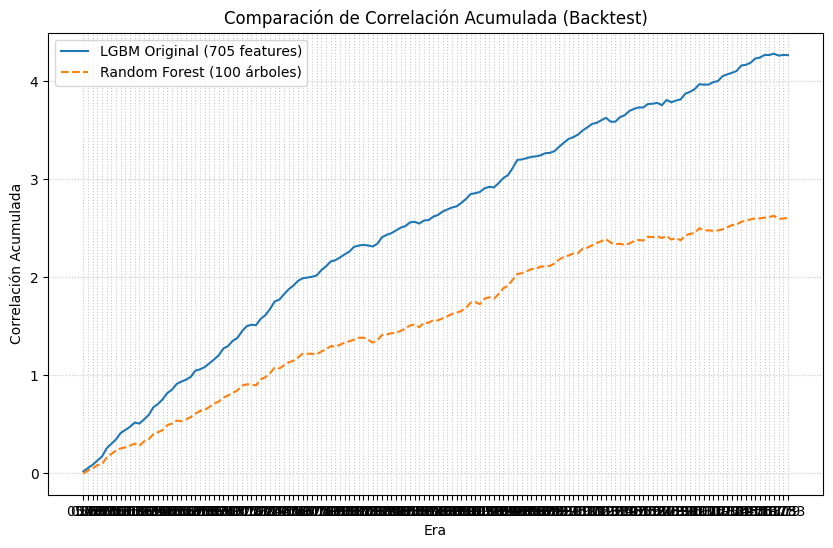

In [22]:
# Crear un DataFrame para comparar las correlaciones acumuladas
df_compare_plot = pd.DataFrame({
    'LGBM_Original_Acumulado': per_era_corr.cumsum(),
    'Random_Forest_Acumulado': per_era_corr_rf.cumsum()
})

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(df_compare_plot.index, df_compare_plot['LGBM_Original_Acumulado'], label='LGBM Original (705 features)')
plt.plot(df_compare_plot.index, df_compare_plot['Random_Forest_Acumulado'], label='Random Forest (100 árboles)', linestyle='--')

plt.title('Comparación de Correlación Acumulada (Backtest)')
plt.xlabel('Era')
plt.ylabel('Correlación Acumulada')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

La grafica muestra como la linea del LGBM se mantiene consistentemente por encima de la del Random Forest. Esto demuestra graficamente lo que muestra la tabla, el modelo LGBM genera predicciones mas precisas, mean mas alto, y lo hace de forma mas constante, sharpe mas alto, a lo largo de las eras de validación.

### Calcula también las métricas de rendimiento (ver ejemplo) y explica el resultado.

In [23]:
# Comparar Resultados
print("\n Original LGBM vs Random Forest")
comparison_df_rf = pd.concat([original_metrics_df, rf_metrics_df], axis=1)
print(comparison_df_rf)


 Original LGBM vs Random Forest
              Original (705 feats)  Random Forest (100 arb)
mean                      0.027900                 0.017137
std                       0.022639                 0.021040
sharpe                    1.232403                 0.814538
max_drawdown              0.036805                 0.057755


El modelo LGBM original es claramente superior al modelo Random Forest con esta configuración.

El mean del LGBM es 0.0279, mientras que el del Random Forest es mucho mas bajo, 0.0171.
El sharpe del LGBM (1.23) tambien es mucho mejor que el del Random Forest (0.81).
El max_drawdown, el Random Forest tuvo una peor racha de pérdidas (0.0577) que el LGBM (0.0368), lo que indica que es un modelo más arriesgado.

Aunque ambos son modelos de arboles, la tecnica de boosting, usada por LGBM, ha funcionado mucho mejor que la de bagging, usada por Random Forest. El boosting parece ser mas efectivo para encontrar y aprovechar las señales predictivas débiles en este dataset tan ruidoso.

In [24]:
from scipy import stats
import numpy as np

# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

Como se mencionó anteriormente, es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\38165613.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))


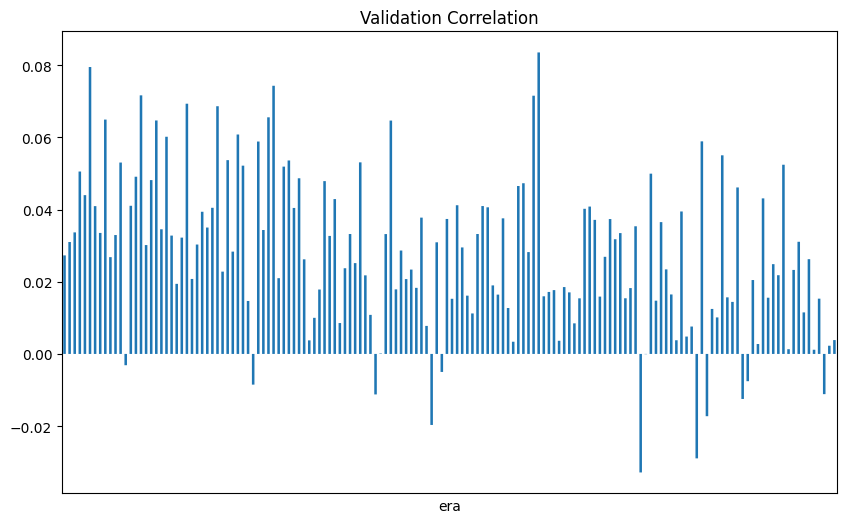

In [25]:
# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

# Gráfica de correlación por "era" 
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

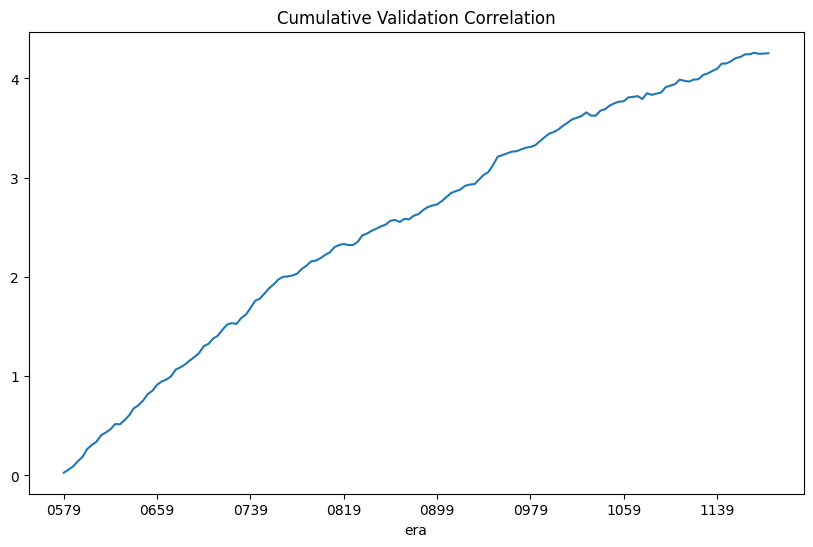

In [26]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Métricas de rendimiento:
    
Para evaluar el rendimiento de nuestro modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento de su modelo.

Sharpe es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (max_drawdown) es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [27]:
# Calcula métricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

,Value
mean,0.027989
std,0.021803
sharpe,1.283711
max_drawdown,0.032897


Estas métricas de rendimiento anteriores no son sorprendentes, pero son lo suficientemente buenas como para comenzar!

# Improvement & Investigation

In [28]:
# Calcular métricas resumen para el modelo original
corr_mean_original = per_era_corr.mean()
corr_std_original = per_era_corr.std(ddof=0)
corr_sharpe_original = corr_mean_original / corr_std_original
max_drawdown_original = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

# Crear el DataFrame de métricas originales
original_metrics_df = pd.DataFrame({
    "mean": corr_mean_original,
    "std": corr_std_original,
    "sharpe": corr_sharpe_original,
    "max_drawdown": max_drawdown_original
}, index=["Original (705 feats)"]).T


# Iniciar Neutralización
NEUTRALIZATION_PROPORTION = 1.0 
print(f"\nIniciando neutralización de características (Proporción: {NEUTRALIZATION_PROPORTION * 100}%)")

validation_neutralized = validation.copy()
eras = validation_neutralized['era'].unique()
neutralized_predictions = []

scaler = StandardScaler()
lr = LinearRegression(fit_intercept=False) 

# Iteramos por cada era para neutralizar
for era in eras:
    era_df = validation_neutralized[validation_neutralized['era'] == era]
    era_preds = era_df["prediction"] # Usamos la predicción del LGBM original
    era_features = era_df[feature_set] 
    
    features_scaled = scaler.fit_transform(era_features)
    
    lr.fit(features_scaled, era_preds)
    exposure_to_risk = lr.predict(features_scaled)
    
    neutralized_preds = era_preds - (NEUTRALIZATION_PROPORTION * exposure_to_risk)
    neutralized_predictions.append(neutralized_preds)

# Concatenamos todas las predicciones neutralizadas
validation_neutralized['prediction_neutralized'] = pd.concat(neutralized_predictions)

# Calcular metricas del modelo neutralizado
per_era_corr_neu = validation_neutralized.groupby("era").apply(
    lambda x: practica_corr(x["prediction_neutralized"], x["target"])
)

corr_mean_neu = per_era_corr_neu.mean()
corr_std_neu = per_era_corr_neu.std(ddof=0)
corr_sharpe_neu = corr_mean_neu / corr_std_neu
max_drawdown_neu = (per_era_corr_neu.cumsum().expanding(min_periods=1).max() - per_era_corr_neu.cumsum()).max()

neu_metrics_df = pd.DataFrame({
    "mean": corr_mean_neu,
    "std": corr_std_neu,
    "sharpe": corr_sharpe_neu,
    "max_drawdown": max_drawdown_neu
}, index=[f"LGBM Neutralizado ({NEUTRALIZATION_PROPORTION * 100}%)"]).T

# Comparar Resultados
print("Original vs Neutralizado")
comparison_df_neu = pd.concat([original_metrics_df, neu_metrics_df], axis=1)
print(comparison_df_neu)


Iniciando neutralización de características (Proporción: 100.0%)
Original vs Neutralizado
              Original (705 feats)  LGBM Neutralizado (100.0%)
mean                      0.027989                    0.022550
std                       0.021803                    0.018183
sharpe                    1.283711                    1.240133
max_drawdown              0.032897                    0.030675


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\1354435095.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_neu = validation_neutralized.groupby("era").apply(


La neutralización al 100% no mejoro el rendimiento general. El Mean bajo de 0.0279 a 0.0225 y el Sharpe tambien se redujo de 1.28 a 1.24.

De todas formas, la neutralización cumplio el objetivo de reducir el riesgo. Hizo que las predicciones fueran menos volatiles, el std bajo, y la peor racha de perdidas, max_drawdown, mejoro, reducirndose de 0.0329 a 0.0307.

Por tanto se sacrifico el Mean para ganar robustez y reducir el riesgo, aunque en este caso el Sharpe empeoro un poco.

In [29]:
print("Iniciando entrenamiento y evaluación del modelo Ridge Regression...")

# Preparar Datos
scaler = StandardScaler()

# Ajustar en train y transformar ambos
train_scaled_features = scaler.fit_transform(train[feature_set])
validation_scaled_features = scaler.transform(validation[feature_set])

# Definir y Entrenar el Modelo Ridge
ridge_model = Ridge(alpha=1.0)

# Entrenar con las features escaladas
ridge_model.fit(
  train_scaled_features,
  train["target"]
)

# Evaluar el Modelo Ridge
validation_ridge = validation.copy()

# Predecir sobre la validación escalada
validation_ridge['prediction_ridge'] = ridge_model.predict(validation_scaled_features)

# Calcular correlación por era
per_era_corr_ridge = validation_ridge.groupby("era").apply(
    lambda x: practica_corr(x["prediction_ridge"], x["target"])
)

# Calcular metricas de rendimiento
corr_mean_ridge = per_era_corr_ridge.mean()
corr_std_ridge = per_era_corr_ridge.std(ddof=0)
corr_sharpe_ridge = corr_mean_ridge / corr_std_ridge
max_drawdown_ridge = (per_era_corr_ridge.cumsum().expanding(min_periods=1).max() - per_era_corr_ridge.cumsum()).max()

ridge_metrics_df = pd.DataFrame({
    "mean": corr_mean_ridge,
    "std": corr_std_ridge,
    "sharpe": corr_sharpe_ridge,
    "max_drawdown": max_drawdown_ridge
}, index=["Ridge (alpha=1.0)"]).T

# Comparar Resultados
print("\nOriginal LGBM vs Ridge")
comparison_df_ridge = pd.concat([original_metrics_df, ridge_metrics_df], axis=1)
print(comparison_df_ridge)

Iniciando entrenamiento y evaluación del modelo Ridge Regression...

Original LGBM vs Ridge
              Original (705 feats)  Ridge (alpha=1.0)
mean                      0.027989           0.015734
std                       0.021803           0.017706
sharpe                    1.283711           0.888661
max_drawdown              0.032897           0.037492


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\884974703.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_ridge = validation_ridge.groupby("era").apply(


El modelo Ridge Regression tuvo un rendimiento mucho peor que el LGBM en todas las metricas.

El Mean cayo de 0.0279 a 0.0157, y el Sharpe se desplomo de 1.28 a 0.88.

Esto puede ser porque Ridge es un modelo lineal. Aunque es bueno para manejar muchas feature, solo puede encontrar patrones lineales. El LGBM, un modelo de arbol, es no lineal y fue mucho mas efectivo capturando las interacciones complejas y debiles de este dataset.

# SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [30]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = model.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-11-04 17:19:25,724 INFO numerapi.utils: target file already exists
2025-11-04 17:19:25,726 INFO numerapi.utils: download complete


,prediction
id,
n00033945c89dc2a,0.498086
n000da32a2de4eb4,0.490653
n0010d47e977cc92,0.504507
n001d6e7f5876c97,0.495851
n002864576a9ecb2,0.485446
...,...
nffc3cc2110aea62,0.512886
nffe2b5eb838a44d,0.511039
nffe32840bab2a91,0.489581


In [31]:

# Obtenemos la importancia del modelo original
feature_importances_df = pd.DataFrame({
    'feature': feature_set,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Calculamos el numero de features del 75%
total_features = len(feature_set)
n_top_features = int(total_features * 0.75) # 528

# Creamos la lista de las mejores caracteristicas
top_75_features = feature_importances_df.head(n_top_features)['feature'].tolist()

print(f"Lista de {len(top_75_features)} características principales obtenida.")

# Definir los hiperparametros del modelo
best_model_params = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'max_depth': 5,
    'num_leaves': 2**5 - 1,
    'colsample_bytree': 0.1,
    'verbose': -1
}

# Entrenar el modelo FINAL (LGBM Top 75%)
final_model = lgb.LGBMRegressor(**best_model_params)

# Entrenamos con el conjunto 'train' usando SÓLO las features del Top 75%
final_model.fit(
    train[top_75_features],
    train["target"]
)
print("Modelo final entrenado.")

# Guardar el modelo con cloudpickle
model_filename = "modelo_lgbm_top75.pkl"
print(f"Guardando el modelo serializado en '{model_filename}'...")

with open(model_filename, "wb") as f:
    cloudpickle.dump(final_model, f)
print(f"¡Éxito! Modelo guardado como '{model_filename}'.")

# Guardar la lista de features
features_filename = "top_75_features.json"
with open(features_filename, "w") as f:
    json.dump(top_75_features, f)

print(f"Lista de características guardada en '{features_filename}'.")

Lista de 528 características principales obtenida.
Modelo final entrenado.
Guardando el modelo serializado en 'modelo_lgbm_top75.pkl'...
¡Éxito! Modelo guardado como 'modelo_lgbm_top75.pkl'.
Lista de características guardada en 'top_75_features.json'.


In [32]:
# Usar el modelo final para predecir sobre el conjunto de validación
validation['prediction_final'] = final_model.predict(validation[top_75_features])

# Calcular la correlación por era
per_era_corr = validation.groupby("era").apply(
    lambda x: practica_corr(x["prediction_final"], x["target"])
)

# Calcular las metricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

# Crear y mostrar el DataFrame de metricas
metrics_df = pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["LGBM Top 75% (528 feats)"]).T

print("\nMétricas de rendimiento para el modelo LGBM Top 75% (final_model):")
print(metrics_df)


Métricas de rendimiento para el modelo LGBM Top 75% (final_model):
              LGBM Top 75% (528 feats)
mean                          0.028124
std                           0.021723
sharpe                        1.294655
max_drawdown                  0.040053


C:\Users\Alex_\AppData\Local\Temp\ipykernel_9944\1988723194.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(
